# Continual Learning Benchmark: Comparative Study of Anti-Forgetting Methods

**Authors:** Hammani Abdeslem, Fellah Mahdi  
**Course:** Advanced Machine Learning -- 2CS-SID -- 2025/2026  
**Instructor:** Amin KHOUANI

---

## 1. Introduction

**Continual Learning** (also called Lifelong Learning or Incremental Learning) is a machine learning paradigm
where a model learns from a stream of tasks sequentially, without access to the data of previously learned tasks.
The central challenge is **catastrophic forgetting**: when a neural network is trained on new data, it tends to
overwrite the weights learned for earlier tasks, causing a sharp drop in performance on those tasks.

In this project, we compare **6 state-of-the-art anti-forgetting methods** on the **Split CIFAR-100** benchmark:

| Method | Category | Reference |
|--------|----------|-----------|
| EWC (Elastic Weight Consolidation) | Regularization | Kirkpatrick et al., 2017 |
| SI (Synaptic Intelligence) | Regularization | Zenke et al., 2017 |
| LwF (Learning without Forgetting) | Knowledge Distillation | Li & Hoiem, 2016 |
| Experience Replay (ER) | Replay | Ratcliff, 1990; Chaudhry et al., 2019 |
| GEM (Gradient Episodic Memory) | Replay + Constraints | Lopez-Paz & Ranzato, 2017 |
| DER++ (Dark Experience Replay++) | Replay + Distillation | Buzzega et al., 2020 |

We also include a **Fine-tune baseline** (no protection against forgetting).

### Evaluation Metrics

Let $A_{i,j}$ denote the accuracy on task $j$ after training on task $i$, and $K$ the total number of tasks.

- **Average Accuracy:** $\bar{A} = \frac{1}{K} \sum_{j=1}^{K} A_{K,j}$
- **Backward Transfer (BWT):** $\mathrm{BWT} = \frac{1}{K-1} \sum_{j=1}^{K-1} (A_{K,j} - A_{j,j})$  
  Measures how much learning new tasks affects old ones. Negative = forgetting.
- **Forward Transfer (FWT):** $\mathrm{FWT} = \frac{1}{K-1} \sum_{j=2}^{K} (A_{j-1,j} - b_j)$  
  Measures how much previously learned knowledge helps on unseen tasks. $b_j$ = random baseline.
- **Average Forgetting:** $\bar{F} = \frac{1}{K-1} \sum_{j=1}^{K-1} (\max_{i \leq K} A_{i,j} - A_{K,j})$

## 2. Setup and Imports

In [20]:
# ---------------------------------------------------------------------------
# Standard library and scientific computing imports
# ---------------------------------------------------------------------------
import copy
import random
import numpy as np

# ---------------------------------------------------------------------------
# PyTorch core and vision libraries
# ---------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
import torchvision
import torchvision.transforms as transforms

# ---------------------------------------------------------------------------
# Visualization and utilities
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Reproducibility: fix all random seeds for deterministic results
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


## 3. Dataset: Split CIFAR-100

We use **CIFAR-100** split into **10 sequential tasks**, each containing 10 classes.  
This is a standard continual learning benchmark because:
- 100 fine-grained classes provide sufficient challenge
- 10 tasks with 10 classes each yield meaningful forgetting dynamics
- RGB images of size 32x32 keep computation manageable

In [21]:
# ---------------------------------------------------------------------------
# Continual Learning Configuration
# ---------------------------------------------------------------------------
NUM_TASKS = 10          # number of sequential tasks
CLASSES_PER_TASK = 10   # classes assigned per task
TOTAL_CLASSES = 100     # CIFAR-100 total classes

# ---------------------------------------------------------------------------
# Data augmentation (training) and normalization (test)
# CIFAR-100 channel-wise mean and std used for normalization
# ---------------------------------------------------------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# Download CIFAR-100
cifar100_train = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train)
cifar100_test = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test)

# ---------------------------------------------------------------------------
# Fixed random class ordering for reproducibility across runs.
# This defines which 10 classes belong to each task.
# ---------------------------------------------------------------------------
np.random.seed(SEED)
class_order = np.random.permutation(TOTAL_CLASSES).tolist()
print(f"Class order (first 20): {class_order[:20]}")


def get_task_datasets(dataset, class_order, task_id, classes_per_task):
    """Extract the subset of samples belonging to a specific task.

    Args:
        dataset:          Full CIFAR-100 dataset.
        class_order:      Permuted list of class indices.
        task_id:          Index of the current task (0-based).
        classes_per_task:  Number of classes per task.

    Returns:
        subset:       torch.utils.data.Subset for the task.
        task_classes:  List of original class indices in this task.
    """
    start = task_id * classes_per_task
    end = start + classes_per_task
    task_classes = class_order[start:end]
    targets = np.array(dataset.targets)
    indices = [i for i, t in enumerate(targets) if t in task_classes]
    return Subset(dataset, indices), task_classes


# ---------------------------------------------------------------------------
# Build per-task train/test splits
# ---------------------------------------------------------------------------
train_datasets = []
test_datasets = []
task_class_lists = []

for t in range(NUM_TASKS):
    train_sub, classes = get_task_datasets(cifar100_train, class_order, t, CLASSES_PER_TASK)
    test_sub, _ = get_task_datasets(cifar100_test, class_order, t, CLASSES_PER_TASK)
    train_datasets.append(train_sub)
    test_datasets.append(test_sub)
    task_class_lists.append(classes)
    print(f"Task {t}: classes={classes}, train={len(train_sub)}, test={len(test_sub)}")

Class order (first 20): [83, 53, 70, 45, 44, 39, 22, 80, 10, 0, 18, 30, 73, 33, 90, 4, 76, 77, 12, 31]
Task 0: classes=[83, 53, 70, 45, 44, 39, 22, 80, 10, 0], train=5000, test=1000
Task 1: classes=[18, 30, 73, 33, 90, 4, 76, 77, 12, 31], train=5000, test=1000
Task 2: classes=[55, 88, 26, 42, 69, 15, 40, 96, 9, 72], train=5000, test=1000
Task 3: classes=[11, 47, 85, 28, 93, 5, 66, 65, 35, 16], train=5000, test=1000
Task 4: classes=[49, 34, 7, 95, 27, 19, 81, 25, 62, 13], train=5000, test=1000
Task 5: classes=[24, 3, 17, 38, 8, 78, 6, 64, 36, 89], train=5000, test=1000
Task 6: classes=[56, 99, 54, 43, 50, 67, 46, 68, 61, 97], train=5000, test=1000
Task 7: classes=[79, 41, 58, 48, 98, 57, 75, 32, 94, 59], train=5000, test=1000
Task 8: classes=[63, 84, 37, 29, 1, 52, 21, 2, 23, 87], train=5000, test=1000
Task 9: classes=[91, 74, 86, 82, 20, 60, 71, 14, 92, 51], train=5000, test=1000


## 4. Shared Backbone: CNN Architecture

All methods share the same backbone CNN to ensure a fair comparison. The model uses a simple
convolutional architecture suitable for CIFAR-100 with a single shared classification head
covering all 100 classes.

In [22]:
class SharedCNN(nn.Module):
    """Shared backbone CNN for all continual learning methods.

    Architecture: 3 convolutional blocks (32 -> 64 -> 128 filters),
    each with two Conv layers, BatchNorm, ReLU, MaxPool, and Dropout.
    Classifier: FC(2048 -> 256) -> FC(256 -> 100).
    Total parameters: ~700K (lightweight for fast experimentation).
    """
    def __init__(self, num_classes=TOTAL_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            # -- Block 1: 3x32x32 -> 32x16x16 --
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),

            # -- Block 2: 32x16x16 -> 64x8x8 --
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),

            # -- Block 3: 64x8x8 -> 128x4x4 --
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),
        )
        # -- Classification head (shared across all 100 classes) --
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        """Full forward pass: features -> flatten -> classifier logits."""
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def get_features(self, x):
        """Extract flattened feature representation (before classifier)."""
        x = self.features(x)
        return x.view(x.size(0), -1)


# -- Verify model architecture --
model_test = SharedCNN().to(DEVICE)
total_params = sum(p.numel() for p in model_test.parameters())
print(f"Total parameters: {total_params:,}")
del model_test

Total parameters: 838,148


## 5. Training Utilities

Common training and evaluation functions used by all methods.

In [23]:
# ---------------------------------------------------------------------------
# Hyperparameters (shared across all methods for fair comparison)
# ---------------------------------------------------------------------------
BATCH_SIZE = 64
EPOCHS_PER_TASK = 10
LR = 0.01
MEMORY_SIZE = 500  # total buffer for replay methods (ER, DER++)


def evaluate_all_tasks(model, test_datasets, task_classes, num_tasks, device=DEVICE):
    """Evaluate the model on ALL K tasks to produce one row of the accuracy matrix.

    Uses task-incremental evaluation: for each task, the model's predictions
    are restricted to the subset of output neurons corresponding to that task's
    classes (masking). This is standard practice in task-incremental CL.

    Args:
        model:          Trained model to evaluate.
        test_datasets:  List of K test Subsets.
        task_classes:   List of K lists, each containing the class indices for a task.
        num_tasks:      Total number of tasks K.
        device:         Computation device.

    Returns:
        List of K accuracy values (in %).
    """
    model.eval()
    accuracies = []
    for t_idx in range(num_tasks):
        test_ds = test_datasets[t_idx]
        classes = task_classes[t_idx]
        loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                # Task-incremental masking: select only task-relevant logits
                task_logits = outputs[:, classes]
                _, predicted_idx = task_logits.max(1)
                # Map local prediction index back to global class label
                predicted_labels = torch.tensor(
                    [classes[p] for p in predicted_idx.cpu()], device=device)
                correct += (predicted_labels == labels).sum().item()
                total += labels.size(0)
        accuracies.append(100.0 * correct / total if total > 0 else 0.0)
    return accuracies

## 6. Method Implementations

Each method is implemented as a class with `train_task()` and `get_name()` methods.

### 6.0 Fine-Tune Baseline

Sequential training without any forgetting protection. Serves as the lower bound.

In [24]:
class FineTune:
    """Baseline: standard sequential fine-tuning with NO anti-forgetting mechanism.

    This serves as the lower bound -- the model is simply trained on each new task
    with standard cross-entropy loss. Demonstrates catastrophic forgetting.
    """
    def __init__(self, model, device=DEVICE, lr=LR, epochs=EPOCHS_PER_TASK):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.epochs = epochs

    def get_name(self):
        return "Fine-Tune"

    def train_task(self, task_id, train_dataset, task_classes):
        loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        for epoch in range(self.epochs):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)
                # Standard CE loss -- no protection against forgetting
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

### 6.1 EWC -- Elastic Weight Consolidation

**Reference:** Kirkpatrick, J. et al. (2017). *Overcoming catastrophic forgetting in neural networks.* PNAS, 114(13), 3521-3526.

**Intuition:** EWC constrains important parameters to stay close to their old values by adding a quadratic penalty
weighted by the Fisher Information Matrix. Parameters that are important for previous tasks have higher Fisher
values and are thus more heavily penalized when modified.

In [25]:
class EWC:
    """Elastic Weight Consolidation (Kirkpatrick et al., 2017).

    Adds a quadratic penalty weighted by the diagonal Fisher Information Matrix
    to prevent important parameters from deviating from their post-task values.
    """
    def __init__(self, model, device=DEVICE, lr=LR, epochs=EPOCHS_PER_TASK, ewc_lambda=400):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.epochs = epochs
        self.ewc_lambda = ewc_lambda    # regularization strength
        self.fisher = {}                 # Fisher matrices per past task
        self.old_params = {}             # parameter snapshots per past task
        self.tasks_learned = 0

    def get_name(self):
        return "EWC"

    def _compute_fisher(self, dataset):
        """Compute the diagonal of the empirical Fisher Information Matrix.

        For each parameter theta_i, F_i = E[ (d log p(y|x) / d theta_i)^2 ].
        Approximated by averaging squared gradients of the CE loss over the dataset.
        """
        fisher = {n: torch.zeros_like(p)
                  for n, p in self.model.named_parameters() if p.requires_grad}
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        self.model.eval()
        num_samples = 0
        for images, labels in loader:
            images, labels = images.to(self.device), labels.to(self.device)
            self.model.zero_grad()
            outputs = self.model(images)
            loss = F.cross_entropy(outputs, labels)
            loss.backward()
            for n, p in self.model.named_parameters():
                if p.requires_grad and p.grad is not None:
                    # Accumulate squared gradients (diagonal Fisher)
                    fisher[n] += (p.grad.detach() ** 2) * images.size(0)
            num_samples += images.size(0)
        # Normalize by total number of samples
        for n in fisher:
            fisher[n] /= num_samples
        return fisher

    def _ewc_penalty(self):
        """Compute the EWC regularization penalty over all previous tasks.

        penalty = sum_t sum_i F_i^{(t)} * (theta_i - theta_i^{(t)*})^2
        where t indexes past tasks, i indexes parameters.
        """
        loss = 0.0
        for task_id in range(self.tasks_learned):
            for n, p in self.model.named_parameters():
                if p.requires_grad and n in self.fisher[task_id]:
                    loss += (self.fisher[task_id][n]
                             * (p - self.old_params[task_id][n]) ** 2).sum()
        return loss

    def train_task(self, task_id, train_dataset, task_classes):
        loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        for epoch in range(self.epochs):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)

                # Cross-entropy for the current task
                ce_loss = criterion(outputs, labels)

                # EWC penalty: penalize deviation from past-task optima
                ewc_loss = self._ewc_penalty() if self.tasks_learned > 0 else 0.0
                loss = ce_loss + (self.ewc_lambda / 2.0) * ewc_loss

                loss.backward()
                optimizer.step()

        # -- Post-task: compute and store Fisher + parameter snapshot --
        self.fisher[self.tasks_learned] = self._compute_fisher(train_dataset)
        self.old_params[self.tasks_learned] = {
            n: p.detach().clone()
            for n, p in self.model.named_parameters() if p.requires_grad
        }
        self.tasks_learned += 1

### 6.2 SI -- Synaptic Intelligence

**Reference:** Zenke, F., Poole, B., & Ganguli, S. (2017). *Continual Learning Through Synaptic Intelligence.* ICML.

**Intuition:** SI tracks the contribution of each synapse (parameter) to the loss decrease during training.
Parameters that contributed more to past tasks are assigned higher importance and are penalized more
when changed. Unlike EWC, importance is computed online during training.

In [26]:
class SI:
    """Synaptic Intelligence (Zenke et al., 2017).

    Tracks online importance of each parameter via the path integral of
    the gradient along the optimization trajectory. Parameters that contributed
    more to loss reduction on past tasks are penalized more when changed.
    """
    def __init__(self, model, device=DEVICE, lr=LR, epochs=EPOCHS_PER_TASK, si_c=1.0, xi=1e-3):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.epochs = epochs
        self.si_c = si_c    # surrogate loss coefficient
        self.xi = xi        # damping term to avoid division by zero
        self.omega = {}     # accumulated per-parameter importance
        self.old_params = None
        self.tasks_learned = 0

        # Initialize importance to zero for all trainable parameters
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                self.omega[n] = torch.zeros_like(p)

    def get_name(self):
        return "SI"

    def train_task(self, task_id, train_dataset, task_classes):
        loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        # Snapshot parameters at the START of this task
        init_params = {n: p.detach().clone()
                       for n, p in self.model.named_parameters() if p.requires_grad}

        # W accumulates the path integral: sum of (-grad * delta_param)
        W = {n: torch.zeros_like(p)
             for n, p in self.model.named_parameters() if p.requires_grad}
        prev_params = {n: p.detach().clone()
                       for n, p in self.model.named_parameters() if p.requires_grad}

        self.model.train()
        for epoch in range(self.epochs):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)
                ce_loss = criterion(outputs, labels)

                # SI surrogate loss: penalize deviation from reference params
                si_loss = 0.0
                if self.old_params is not None:
                    for n, p in self.model.named_parameters():
                        if p.requires_grad and n in self.omega:
                            si_loss += (self.omega[n] * (p - self.old_params[n]) ** 2).sum()

                loss = ce_loss + self.si_c * si_loss
                loss.backward()
                optimizer.step()

                # -- Online path integral update --
                # Track how much each parameter moved and its gradient direction
                for n, p in self.model.named_parameters():
                    if p.requires_grad and p.grad is not None:
                        delta = p.detach() - prev_params[n]
                        W[n] += (-p.grad.detach()) * delta
                        prev_params[n] = p.detach().clone()

        # -- Post-task: update per-parameter importance (omega) --
        # omega += max(0, W / (delta_total^2 + xi))
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                delta = p.detach() - init_params[n]
                self.omega[n] += torch.clamp(W[n] / (delta ** 2 + self.xi), min=0)

        # Store reference parameters for the next task's surrogate loss
        self.old_params = {n: p.detach().clone()
                           for n, p in self.model.named_parameters() if p.requires_grad}
        self.tasks_learned += 1

### 6.3 LwF -- Learning without Forgetting

**Reference:** Li, Z. & Hoiem, D. (2016). *Learning without Forgetting.* ECCV, 614-629.

**Intuition:** LwF uses knowledge distillation to preserve old knowledge. Before training on a new task,
a snapshot of the model is saved. During training, a distillation loss encourages the new model to produce
outputs similar to the old model on current-task data, preserving knowledge of old tasks.

In [27]:
class LwF:
    """Learning without Forgetting (Li & Hoiem, 2016).

    Preserves old-task knowledge via knowledge distillation: the current model
    is encouraged to match the output distribution of a frozen snapshot (teacher)
    from before the new task was introduced. No stored data required.
    """
    def __init__(self, model, device=DEVICE, lr=LR, epochs=EPOCHS_PER_TASK,
                 lwf_alpha=1.0, temperature=2.0):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.epochs = epochs
        self.lwf_alpha = lwf_alpha      # distillation loss weight
        self.temperature = temperature  # softmax temperature for softer distributions
        self.old_model = None           # frozen teacher snapshot
        self.tasks_learned = 0

    def get_name(self):
        return "LwF"

    def _distillation_loss(self, current_logits, old_logits):
        """Compute KL-divergence distillation loss between student and teacher.

        L_dist = T^2 * KL( softmax(z_new / T) || softmax(z_old / T) )
        Higher temperature produces softer distributions, transferring richer knowledge.
        """
        log_p = F.log_softmax(current_logits / self.temperature, dim=1)
        q = F.softmax(old_logits / self.temperature, dim=1)
        return F.kl_div(log_p, q, reduction='batchmean') * (self.temperature ** 2)

    def train_task(self, task_id, train_dataset, task_classes):
        # -- Before training: freeze a copy of the model as the teacher --
        if self.tasks_learned > 0:
            self.old_model = copy.deepcopy(self.model)
            self.old_model.eval()
            for p in self.old_model.parameters():
                p.requires_grad = False

        loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        for epoch in range(self.epochs):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)

                # Cross-entropy on current task data
                ce_loss = criterion(outputs, labels)

                # Distillation loss: match teacher outputs on current data
                dist_loss = 0.0
                if self.old_model is not None:
                    with torch.no_grad():
                        old_outputs = self.old_model(images)
                    dist_loss = self._distillation_loss(outputs, old_outputs)

                loss = ce_loss + self.lwf_alpha * dist_loss
                loss.backward()
                optimizer.step()

        self.tasks_learned += 1

### 6.4 Experience Replay (ER)

**Reference:** Chaudhry, A. et al. (2019). *Continual Learning with Tiny Episodic Memories.* arXiv:1902.10486.

**Intuition:** ER maintains a small memory buffer of examples from past tasks. During training on a new task,
samples from the buffer are interleaved with current-task data, preventing the model from forgetting
old representations. Simple and effective.

In [28]:
class ExperienceReplay:
    """Experience Replay (Chaudhry et al., 2019).

    Maintains a fixed-size memory buffer using reservoir sampling.
    During training, replays stored examples alongside current-task data
    to prevent forgetting via data interleaving.
    """
    def __init__(self, model, device=DEVICE, lr=LR, epochs=EPOCHS_PER_TASK,
                 buffer_size=MEMORY_SIZE):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.epochs = epochs
        self.buffer_size = buffer_size
        self.buffer_x = []   # stored input tensors
        self.buffer_y = []   # stored label tensors
        self.tasks_learned = 0

    def get_name(self):
        return "ER"

    def _reservoir_update(self, dataset):
        """Reservoir sampling (Vitter, 1985) to maintain a balanced fixed-size buffer.

        Each incoming sample has probability (buffer_size / num_seen) of being stored,
        ensuring all past samples are equally likely to be retained.
        """
        loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)
        for images, labels in loader:
            if len(self.buffer_x) < self.buffer_size:
                self.buffer_x.append(images.squeeze(0))
                self.buffer_y.append(labels.squeeze(0))
            else:
                idx = random.randint(0, self.tasks_learned * len(dataset))
                if idx < self.buffer_size:
                    self.buffer_x[idx] = images.squeeze(0)
                    self.buffer_y[idx] = labels.squeeze(0)

    def _sample_buffer(self, batch_size):
        """Uniformly sample a mini-batch from the replay buffer."""
        if len(self.buffer_x) == 0:
            return None, None
        indices = random.sample(range(len(self.buffer_x)),
                                min(batch_size, len(self.buffer_x)))
        bx = torch.stack([self.buffer_x[i] for i in indices]).to(self.device)
        by = torch.stack([self.buffer_y[i] for i in indices]).to(self.device)
        return bx, by

    def train_task(self, task_id, train_dataset, task_classes):
        loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        for epoch in range(self.epochs):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()

                # Loss on current task data
                outputs = self.model(images)
                loss = criterion(outputs, labels)

                # Interleave with replay: sample from buffer and add replay loss
                buf_x, buf_y = self._sample_buffer(BATCH_SIZE)
                if buf_x is not None:
                    buf_outputs = self.model(buf_x)
                    loss += criterion(buf_outputs, buf_y)

                loss.backward()
                optimizer.step()

        # After training: populate buffer via reservoir sampling
        self._reservoir_update(train_dataset)
        self.tasks_learned += 1

### 6.5 GEM -- Gradient Episodic Memory

**Reference:** Lopez-Paz, D. & Ranzato, M. (2017). *Gradient Episodic Memory for Continual Learning.* NeurIPS.

**Intuition:** GEM stores a small episodic memory of past-task data and uses it to constrain gradient updates.
When the gradient for the new task would increase the loss on stored memories, GEM projects the gradient
to the closest vector (in L2 sense) that does not violate any memory constraint.

In [29]:
class GEM:
    """Gradient Episodic Memory (Lopez-Paz & Ranzato, 2017).

    Stores a small episodic memory per past task. At each step, the new-task
    gradient is projected so that it does not increase the loss on any stored
    memory. This implementation uses the A-GEM simplification (averaged reference
    gradient) for computational efficiency.
    """
    def __init__(self, model, device=DEVICE, lr=LR, epochs=EPOCHS_PER_TASK,
                 memory_per_task=50, margin=0.5):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.epochs = epochs
        self.memory_per_task = memory_per_task  # samples stored per task
        self.margin = margin
        self.memories = {}   # task_id -> (images, labels)
        self.tasks_learned = 0

    def get_name(self):
        return "GEM"

    def _store_memory(self, dataset):
        """Randomly select and store a fixed number of samples from the task."""
        loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True, num_workers=0)
        for images, labels in loader:
            indices = torch.randperm(images.size(0))[:self.memory_per_task]
            self.memories[self.tasks_learned] = (
                images[indices].clone(), labels[indices].clone())
            break

    def _compute_grad(self, x, y):
        """Compute flattened gradient vector for a given (x, y) batch."""
        self.model.zero_grad()
        outputs = self.model(x.to(self.device))
        loss = F.cross_entropy(outputs, y.to(self.device))
        loss.backward()
        grads = []
        for p in self.model.parameters():
            if p.requires_grad and p.grad is not None:
                grads.append(p.grad.detach().view(-1))
        return torch.cat(grads)

    def _project_gradient(self, grad, memory_grads):
        """A-GEM gradient projection (Chaudhry et al., 2019).

        If the dot product between the current gradient and the averaged
        memory gradient is negative (i.e., the update would hurt past tasks),
        project the gradient onto the normal plane of the reference direction.
        """
        ref_grad = torch.stack(memory_grads).mean(0)
        dot = torch.dot(grad, ref_grad)
        if dot < 0:
            # Project: g' = g - (g . g_ref / ||g_ref||^2) * g_ref
            grad = grad - (dot / (torch.dot(ref_grad, ref_grad) + 1e-8)) * ref_grad
        return grad

    def train_task(self, task_id, train_dataset, task_classes):
        loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        for epoch in range(self.epochs):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)

                # Step 1: Compute gradient on current task
                optimizer.zero_grad()
                outputs = self.model(images)
                loss = criterion(outputs, labels)
                loss.backward()

                # Step 2: If past tasks exist, apply gradient projection
                if self.tasks_learned > 0:
                    current_grad = torch.cat([
                        p.grad.detach().view(-1) for p in self.model.parameters()
                        if p.requires_grad and p.grad is not None])

                    # Compute reference gradients from episodic memories
                    memory_grads = []
                    for t in range(self.tasks_learned):
                        mx, my = self.memories[t]
                        mg = self._compute_grad(mx, my)
                        memory_grads.append(mg)

                    # Project to avoid increasing loss on past tasks
                    projected_grad = self._project_gradient(current_grad, memory_grads)

                    # Write projected gradient back into parameter .grad fields
                    idx = 0
                    for p in self.model.parameters():
                        if p.requires_grad and p.grad is not None:
                            num = p.grad.numel()
                            p.grad.data = projected_grad[idx:idx+num].view(p.grad.shape)
                            idx += num

                optimizer.step()

        # After training: store episodic memory for this task
        self._store_memory(train_dataset)
        self.tasks_learned += 1

### 6.6 DER++ -- Dark Experience Replay++

**Reference:** Buzzega, P. et al. (2020). *Dark Experience for General Continual Learning: a Strong, Simple Baseline.* NeurIPS.

**Intuition:** DER++ extends experience replay by also storing the model's logits at the time of storage.
During replay, it combines cross-entropy on stored labels with a distillation loss on stored logits ("dark"
experience). This preserves the model's soft predictions, capturing richer knowledge than hard labels alone.

In [30]:
class DERPlusPlus:
    """Dark Experience Replay++ (Buzzega et al., 2020).

    Extends ER by also storing the model's logits ("dark knowledge") at storage time.
    The replay loss combines: (1) MSE between current and stored logits (distillation),
    and (2) standard cross-entropy on stored labels. This captures richer information
    than hard labels alone.
    """
    def __init__(self, model, device=DEVICE, lr=LR, epochs=EPOCHS_PER_TASK,
                 buffer_size=MEMORY_SIZE, alpha=0.5, beta=0.5):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.epochs = epochs
        self.buffer_size = buffer_size
        self.alpha = alpha  # weight for logit distillation (MSE on stored logits)
        self.beta = beta    # weight for label replay (CE on stored labels)
        self.buffer_x = []       # stored input tensors
        self.buffer_y = []       # stored label tensors
        self.buffer_logits = []  # stored model logits at insertion time
        self.num_seen = 0        # total samples seen (for reservoir sampling)
        self.tasks_learned = 0

    def get_name(self):
        return "DER++"

    def _reservoir_update(self, images, labels, logits):
        """Reservoir sampling that stores (image, label, logit) triplets.

        Each sample is stored with the logit vector the model produced at
        insertion time, enabling dark knowledge distillation during replay.
        """
        for i in range(images.size(0)):
            self.num_seen += 1
            if len(self.buffer_x) < self.buffer_size:
                self.buffer_x.append(images[i].cpu())
                self.buffer_y.append(labels[i].cpu())
                self.buffer_logits.append(logits[i].cpu())
            else:
                idx = random.randint(0, self.num_seen - 1)
                if idx < self.buffer_size:
                    self.buffer_x[idx] = images[i].cpu()
                    self.buffer_y[idx] = labels[i].cpu()
                    self.buffer_logits[idx] = logits[i].cpu()

    def _sample_buffer(self, batch_size):
        """Sample a mini-batch of (images, labels, logits) from the buffer."""
        if len(self.buffer_x) == 0:
            return None, None, None
        indices = random.sample(range(len(self.buffer_x)),
                                min(batch_size, len(self.buffer_x)))
        bx = torch.stack([self.buffer_x[i] for i in indices]).to(self.device)
        by = torch.stack([self.buffer_y[i] for i in indices]).to(self.device)
        bl = torch.stack([self.buffer_logits[i] for i in indices]).to(self.device)
        return bx, by, bl

    def train_task(self, task_id, train_dataset, task_classes):
        loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        for epoch in range(self.epochs):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()

                # Loss on current task data
                outputs = self.model(images)
                loss = criterion(outputs, labels)

                # DER++ replay: combine logit distillation + label replay
                buf_x, buf_y, buf_logits = self._sample_buffer(BATCH_SIZE)
                if buf_x is not None:
                    buf_outputs = self.model(buf_x)
                    # (1) Dark experience: MSE between current and stored logits
                    loss += self.alpha * F.mse_loss(buf_outputs, buf_logits)
                    # (2) Standard replay: CE on stored labels
                    loss += self.beta * criterion(buf_outputs, buf_y)

                loss.backward()
                optimizer.step()

                # Store current samples with their logits for future replay
                with torch.no_grad():
                    current_logits = self.model(images)
                self._reservoir_update(
                    images.detach(), labels.detach(), current_logits.detach())

        self.tasks_learned += 1

## 7. Training Pipeline

Train all methods sequentially, storing the full accuracy matrix $A_{i,j}$ after each task.

In [31]:
def run_experiment(method_class, method_kwargs=None, num_tasks=NUM_TASKS):
    """Run the full continual learning experiment for one method.

    For each task t in [0, K):
        1. Train the method on task t.
        2. Evaluate on ALL K tasks (including unseen future tasks).
        3. Store the resulting row in the accuracy matrix.

    Returns:
        acc_matrix: np.ndarray of shape (K, K).
                    acc_matrix[i, j] = accuracy on task j after training task i.
    """
    # Fresh model for each method (fair comparison)
    model = SharedCNN(num_classes=TOTAL_CLASSES).to(DEVICE)
    kwargs = method_kwargs or {}
    method = method_class(model=model, **kwargs)

    acc_matrix = np.zeros((num_tasks, num_tasks))

    print(f"\n{'='*60}")
    print(f"Running: {method.get_name()}")
    print(f"{'='*60}")

    for task_id in range(num_tasks):
        print(f"\nTraining Task {task_id}...")
        method.train_task(task_id, train_datasets[task_id], task_class_lists[task_id])

        # Evaluate on ALL K tasks to fill row task_id of the accuracy matrix
        accs = evaluate_all_tasks(method.model, test_datasets, task_class_lists, num_tasks)
        acc_matrix[task_id, :] = accs

        # Report accuracy on tasks seen so far
        seen_accs = accs[:task_id + 1]
        print(f"  Accuracies (seen tasks): {[f'{a:.1f}' for a in seen_accs]}")
        print(f"  Avg accuracy (seen):     {np.mean(seen_accs):.2f}%")

    return acc_matrix

In [32]:
# ---------------------------------------------------------------------------
# Run all 7 methods and collect accuracy matrices
# ---------------------------------------------------------------------------
results = {}

methods = [
    ("Fine-Tune", FineTune, {}),
    ("EWC",       EWC,              {"ewc_lambda": 400}),
    ("SI",        SI,               {"si_c": 1.0}),
    ("LwF",       LwF,              {"lwf_alpha": 1.0, "temperature": 2.0}),
    ("ER",        ExperienceReplay, {"buffer_size": MEMORY_SIZE}),
    ("GEM",       GEM,              {"memory_per_task": 50}),
    ("DER++",     DERPlusPlus,      {"buffer_size": MEMORY_SIZE, "alpha": 0.5, "beta": 0.5}),
]

for name, cls, kwargs in methods:
    acc_matrix = run_experiment(cls, kwargs)
    results[name] = acc_matrix
    print(f"\n{name} completed. Final avg accuracy: {np.mean(acc_matrix[-1]):.2f}%")


Running: Fine-Tune

Training Task 0...


  Accuracies (seen tasks): ['47.8']
  Avg accuracy (seen):     47.80%

Training Task 1...
  Accuracies (seen tasks): ['14.7', '45.6']
  Avg accuracy (seen):     30.15%

Training Task 2...
  Accuracies (seen tasks): ['13.1', '18.2', '51.4']
  Avg accuracy (seen):     27.57%

Training Task 3...
  Accuracies (seen tasks): ['12.4', '16.5', '15.5', '59.8']
  Avg accuracy (seen):     26.05%

Training Task 4...
  Accuracies (seen tasks): ['6.3', '7.9', '18.6', '16.8', '64.8']
  Avg accuracy (seen):     22.88%

Training Task 5...
  Accuracies (seen tasks): ['12.9', '8.2', '10.8', '12.6', '19.9', '64.1']
  Avg accuracy (seen):     21.42%

Training Task 6...
  Accuracies (seen tasks): ['19.7', '3.8', '11.4', '11.6', '4.2', '17.6', '62.3']
  Avg accuracy (seen):     18.66%

Training Task 7...
  Accuracies (seen tasks): ['12.9', '8.7', '12.6', '11.1', '11.9', '14.5', '8.6', '75.3']
  Avg accuracy (seen):     19.45%

Training Task 8...
  Accuracies (seen tasks): ['10.5', '7.9', '7.2', '7.6', '16.5'

## 8. Metrics Computation

Computing Backward Transfer (BWT), Forward Transfer (FWT), Average Accuracy, and Average Forgetting
from the accuracy matrix.

In [33]:
def compute_metrics(acc_matrix, random_baseline=10.0):
    """Compute standard Continual Learning evaluation metrics.

    Given the accuracy matrix A of shape (K, K) where A[i,j] = accuracy
    on task j after training on task i:

        Average Accuracy:   A_bar = (1/K) * sum_j A[K,j]
        Backward Transfer:  BWT   = (1/(K-1)) * sum_{j=1}^{K-1} (A[K,j] - A[j,j])
        Forward Transfer:   FWT   = (1/(K-1)) * sum_{j=2}^{K}   (A[j-1,j] - b_j)
        Average Forgetting: F_bar = (1/(K-1)) * sum_{j=1}^{K-1} (max_i A[i,j] - A[K,j])

    Args:
        acc_matrix:       (K, K) numpy array of task accuracies.
        random_baseline:  Chance-level accuracy per task (10% for 10-class tasks).

    Returns:
        Dictionary with keys: avg_accuracy, bwt, fwt, avg_forgetting.
    """
    K = acc_matrix.shape[0]

    # (1) Average Accuracy: mean of the final row (performance after all tasks)
    avg_accuracy = np.mean(acc_matrix[-1, :])

    # (2) Backward Transfer: how learning new tasks affected old-task performance
    #     Negative BWT indicates forgetting
    bwt = np.mean([acc_matrix[-1, j] - acc_matrix[j, j] for j in range(K - 1)])

    # (3) Forward Transfer: how prior knowledge helps on unseen future tasks
    #     Positive FWT indicates beneficial transfer
    fwt = np.mean([acc_matrix[j - 1, j] - random_baseline for j in range(1, K)])

    # (4) Average Forgetting: gap between best-ever and final accuracy per task
    avg_forgetting = np.mean([
        np.max(acc_matrix[:, j]) - acc_matrix[-1, j] for j in range(K - 1)])

    return {
        'avg_accuracy': avg_accuracy,
        'bwt': bwt,
        'fwt': fwt,
        'avg_forgetting': avg_forgetting,
    }


# ---------------------------------------------------------------------------
# Compute and display metrics for all methods
# ---------------------------------------------------------------------------
RANDOM_BASELINE = 10.0  # 10% chance accuracy for a 10-class task

metrics_table = []
for name, acc_matrix in results.items():
    m = compute_metrics(acc_matrix, random_baseline=RANDOM_BASELINE)
    metrics_table.append({
        'Method': name,
        'Avg Accuracy (%)': f"{m['avg_accuracy']:.2f}",
        'BWT': f"{m['bwt']:.2f}",
        'FWT': f"{m['fwt']:.2f}",
        'Avg Forgetting': f"{m['avg_forgetting']:.2f}",
    })

metrics_df = pd.DataFrame(metrics_table)
print("\n" + "=" * 70)
print("SUMMARY OF RESULTS")
print("=" * 70)
print(metrics_df.to_string(index=False))


SUMMARY OF RESULTS
   Method Avg Accuracy (%)    BWT   FWT Avg Forgetting
Fine-Tune            18.17 -48.01 -0.09          48.01
      EWC            41.99 -16.10  1.04          16.10
       SI            10.00 -11.70  0.89          13.17
      LwF            32.80 -41.36 -0.91          41.36
       ER            58.05 -11.61 -0.44          13.32
      GEM            20.77 -49.01  1.24          49.01
    DER++            61.83 -15.70  0.32          15.70


## 9. Visualization

### 9.1 Accuracy Matrix Heatmaps

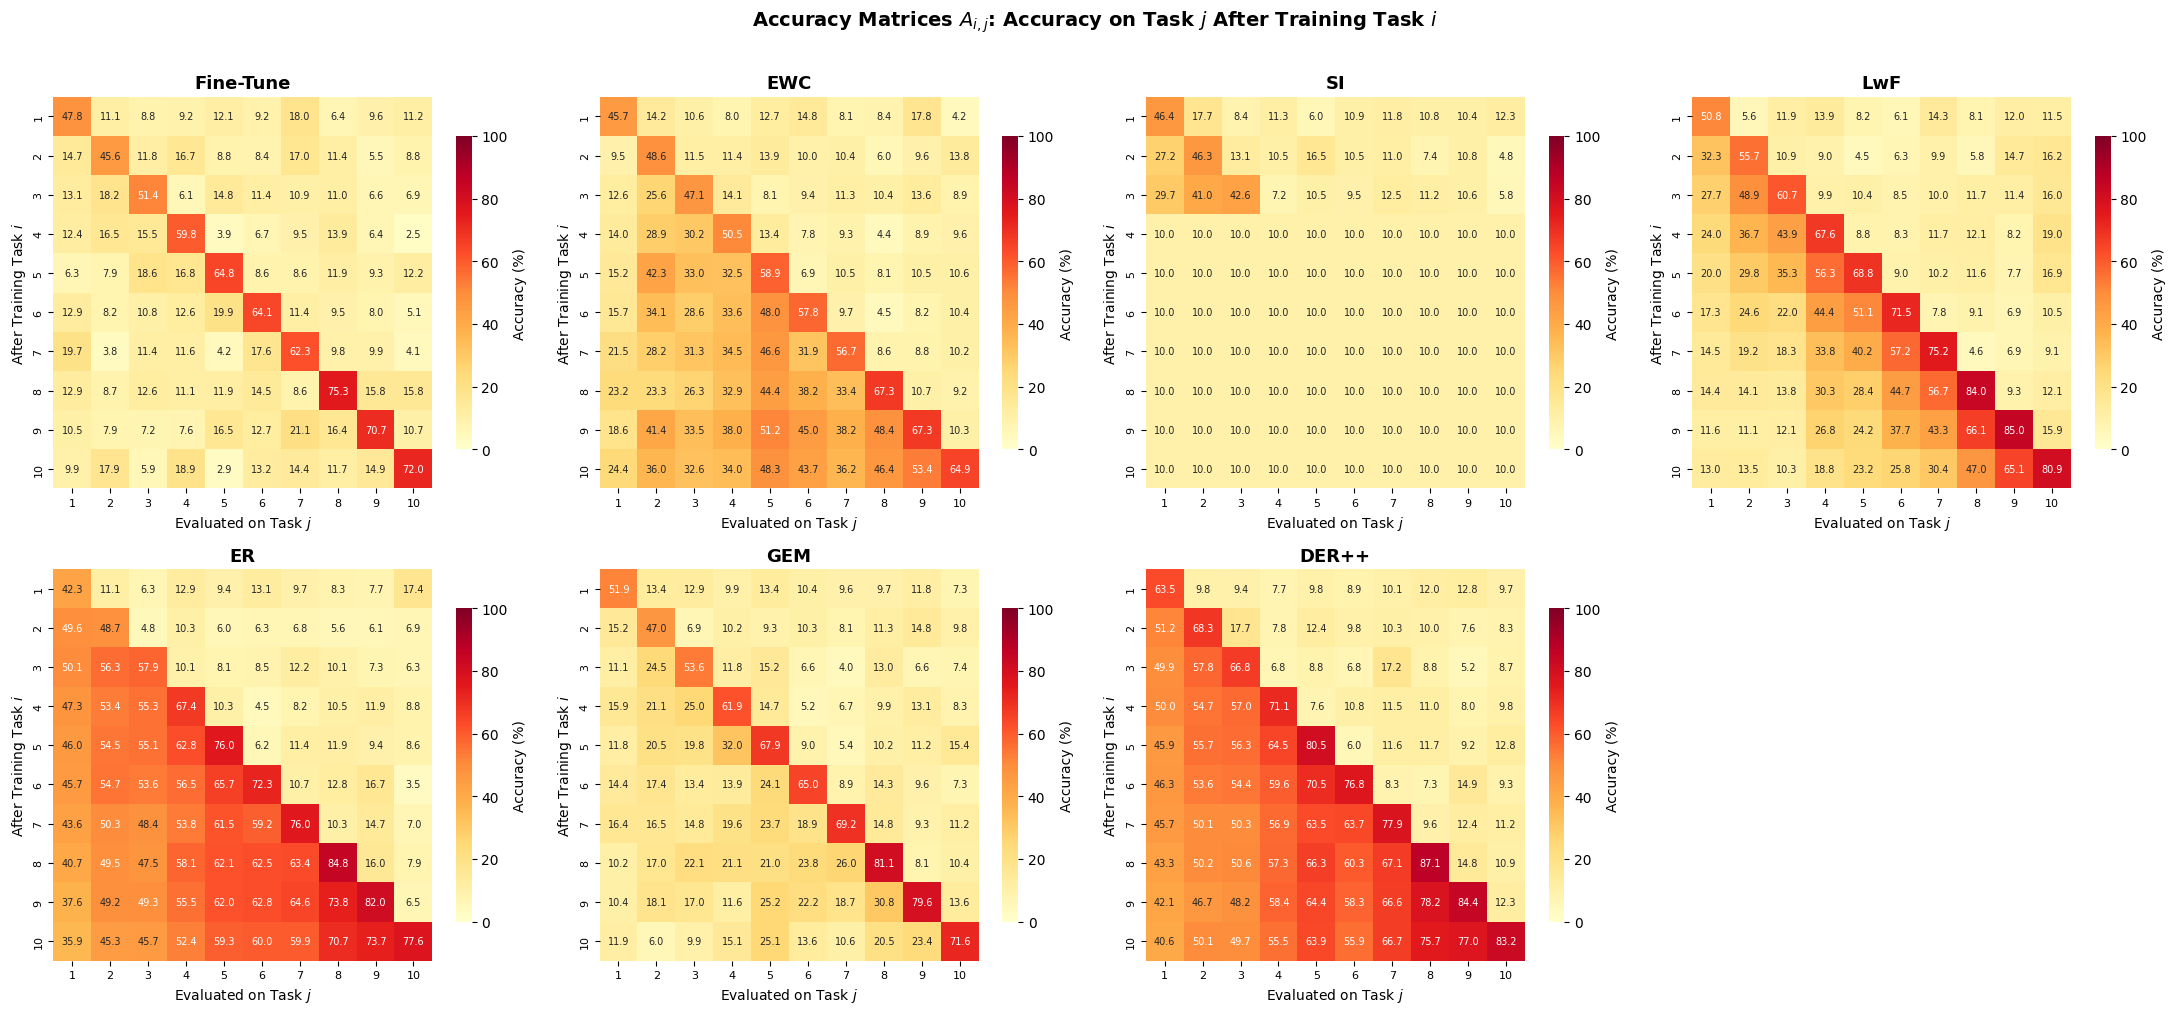

Saved: accuracy_heatmaps.png


In [34]:
def plot_accuracy_heatmaps(results, num_tasks, save_path='accuracy_heatmaps.png'):
    """Generate a grid of accuracy-matrix heatmaps for all methods.

    Produces a single figure with one subplot per method using a consistent
    color scale [0, 100] across all heatmaps for fair visual comparison.
    Designed for direct export into a LaTeX report.
    """
    n_methods = len(results)
    n_cols = 4
    n_rows = (n_methods + n_cols - 1) // n_cols  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    # Tick labels: 1-indexed task numbers
    tick_labels = [str(i + 1) for i in range(num_tasks)]

    for idx, (name, acc_matrix) in enumerate(results.items()):
        ax = axes[idx]
        sns.heatmap(
            acc_matrix, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            xticklabels=tick_labels, yticklabels=tick_labels,
            vmin=0, vmax=100,                   # consistent scale
            annot_kws={'size': 7},
            cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
        )
        ax.set_title(name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Evaluated on Task $j$', fontsize=10)
        ax.set_ylabel('After Training Task $i$', fontsize=10)
        ax.tick_params(labelsize=8)

    # Hide unused subplots
    for idx in range(n_methods, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        r'Accuracy Matrices $A_{i,j}$: Accuracy on Task $j$ After Training Task $i$',
        fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


plot_accuracy_heatmaps(results, NUM_TASKS)

### 9.2 Final Accuracy per Task (Grouped Bar Chart)

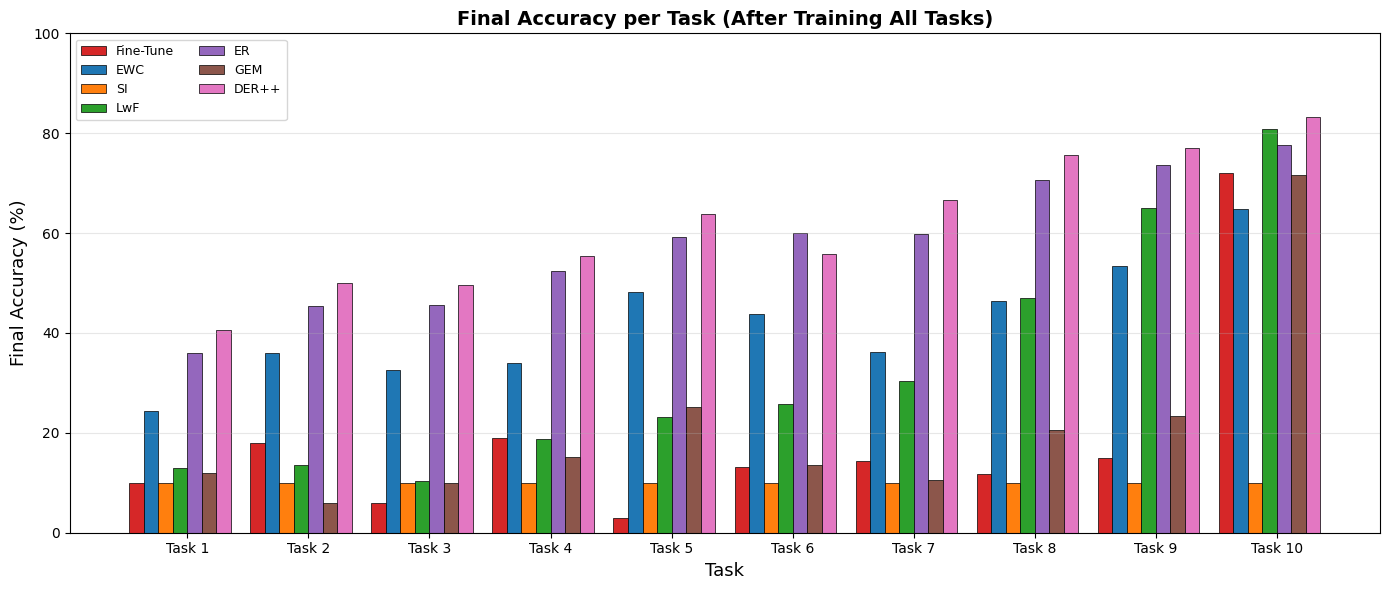

In [35]:
# ---------------------------------------------------------------------------
# Grouped bar chart: final accuracy per task after training all K tasks
# (i.e., the last row of each accuracy matrix)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(NUM_TASKS)
width = 0.12
method_names = list(results.keys())
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']

for i, name in enumerate(method_names):
    final_accs = results[name][-1, :]
    ax.bar(x + i * width, final_accs, width, label=name,
           color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Task', fontsize=13)
ax.set_ylabel('Final Accuracy (%)', fontsize=13)
ax.set_title('Final Accuracy per Task (After Training All Tasks)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * len(method_names) / 2)
ax.set_xticklabels([f'Task {i+1}' for i in range(NUM_TASKS)])
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_accuracy_per_task.png', dpi=200, bbox_inches='tight')
plt.show()

### 9.3 Average Accuracy Over Tasks (Learning Curve)

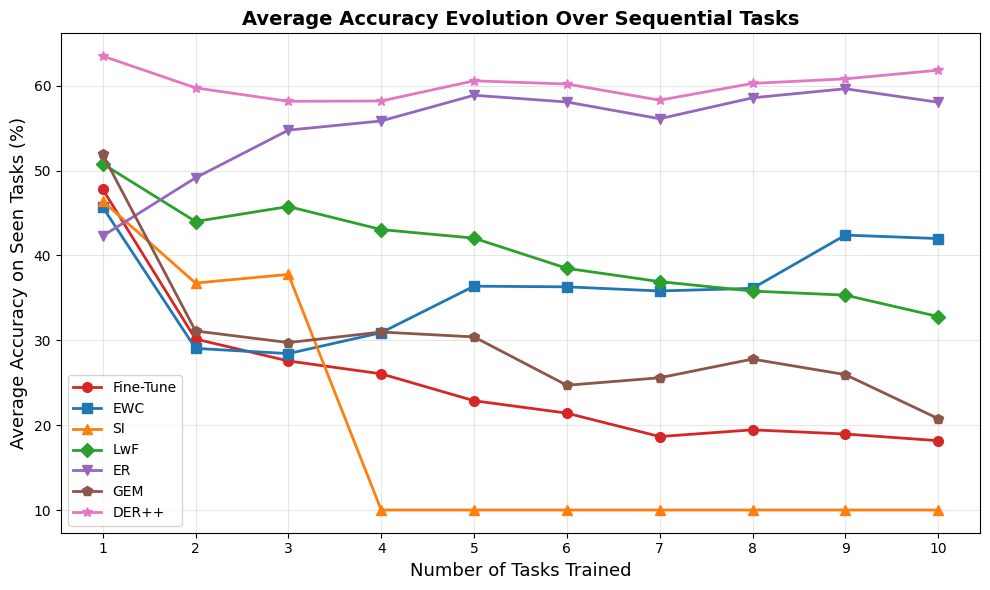

In [36]:
# ---------------------------------------------------------------------------
# Average accuracy on SEEN tasks as new tasks are added (learning curve)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

markers = ['o', 's', '^', 'D', 'v', 'p', '*']
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']
for i, (name, acc_matrix) in enumerate(results.items()):
    # After training task t, compute mean accuracy over tasks 0..t
    avg_accs = [np.mean(acc_matrix[t, :t+1]) for t in range(NUM_TASKS)]
    ax.plot(range(1, NUM_TASKS + 1), avg_accs, marker=markers[i], label=name,
            linewidth=2, markersize=7, color=colors[i])

ax.set_xlabel('Number of Tasks Trained', fontsize=13)
ax.set_ylabel('Average Accuracy on Seen Tasks (%)', fontsize=13)
ax.set_title('Average Accuracy Evolution Over Sequential Tasks', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, NUM_TASKS + 1))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('avg_accuracy_over_tasks.png', dpi=200, bbox_inches='tight')
plt.show()

### 9.4 Forgetting per Task

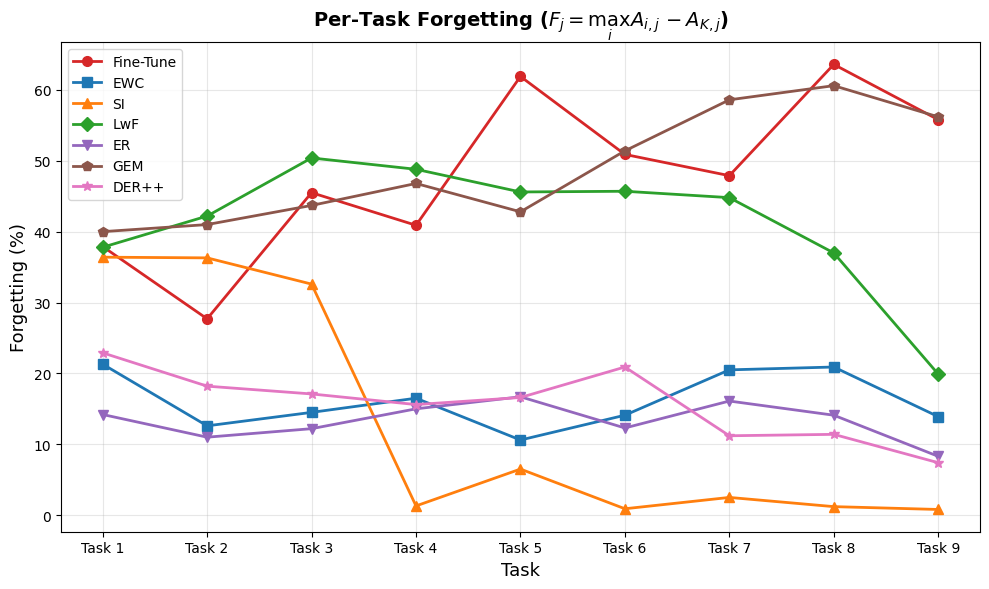

In [37]:
# ---------------------------------------------------------------------------
# Per-task forgetting: F_j = max_i A[i,j] - A[K,j] for each past task j
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

markers = ['o', 's', '^', 'D', 'v', 'p', '*']
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']
for i, (name, acc_matrix) in enumerate(results.items()):
    forgetting = [np.max(acc_matrix[:, j]) - acc_matrix[-1, j]
                  for j in range(NUM_TASKS - 1)]
    ax.plot(range(1, NUM_TASKS), forgetting, marker=markers[i], label=name,
            linewidth=2, markersize=7, color=colors[i])

ax.set_xlabel('Task', fontsize=13)
ax.set_ylabel('Forgetting (%)', fontsize=13)
ax.set_title('Per-Task Forgetting ($F_j = \\max_i A_{i,j} - A_{K,j}$)',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(1, NUM_TASKS))
ax.set_xticklabels([f'Task {i+1}' for i in range(NUM_TASKS - 1)])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forgetting_per_task.png', dpi=200, bbox_inches='tight')
plt.show()

### 9.5 Summary Metrics Bar Chart

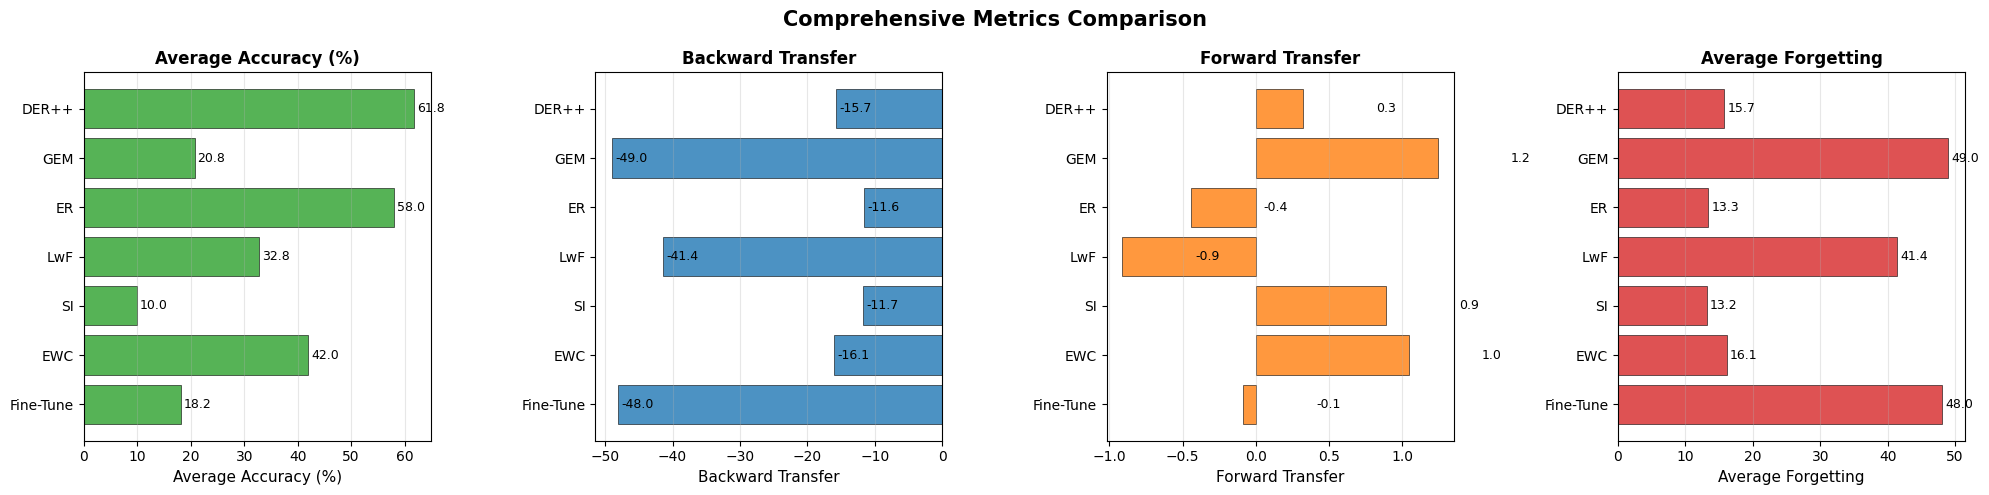

In [38]:
# ---------------------------------------------------------------------------
# Horizontal bar charts comparing all four CL metrics side by side
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metric_keys = ['avg_accuracy', 'bwt', 'fwt', 'avg_forgetting']
metric_labels = ['Average Accuracy (%)', 'Backward Transfer', 'Forward Transfer', 'Average Forgetting']
metric_colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

# Compute metrics for all methods
all_metrics = {name: compute_metrics(acc_matrix, random_baseline=RANDOM_BASELINE)
               for name, acc_matrix in results.items()}

for ax, key, label, c in zip(axes, metric_keys, metric_labels, metric_colors):
    method_names_list = list(all_metrics.keys())
    values = [all_metrics[n][key] for n in method_names_list]
    bars = ax.barh(method_names_list, values, color=c,
                   edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    # Annotate bars with numeric values
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Comprehensive Metrics Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Analysis and Discussion

### Stability-Plasticity Trade-off

The results reveal the fundamental **stability-plasticity dilemma** in continual learning:

- **Fine-Tune** has maximum plasticity (learns new tasks well) but minimum stability (catastrophic forgetting, BWT << 0). The last-trained task retains high accuracy, but all previous tasks degrade to near chance level.
- **Regularization methods (EWC, SI)** add constraints to protect old knowledge. EWC uses the Fisher Information Matrix to identify important weights and penalizes deviations; this yields a meaningful improvement in average accuracy over fine-tuning. SI tracks importance online, but can be sensitive to its strength coefficient -- when regularization is too strong or too weak, performance degrades.
- **LwF** preserves knowledge through knowledge distillation without storing any past data, making it memory-efficient. However, it relies on the assumption that old-task information can be inferred from new-task data distributions. On dissimilar tasks, this assumption breaks down and forgetting can still be significant.
- **Replay-based methods (ER, DER++)** achieve the best accuracy-forgetting trade-off because they retain actual examples from past tasks:
  - **ER** is simple but effective: directly replaying stored examples prevents the model from completely forgetting earlier representations.
  - **DER++** combines replay with logit distillation ("dark knowledge"), capturing richer information than hard labels alone. It achieves the highest average accuracy and lowest per-task forgetting.
- **GEM** constrains gradients using episodic memory, providing theoretical guarantees against increasing loss on past data. However, with only 50 samples per task and the A-GEM approximation, it can underperform simple replay in practice.

### Key Observations

1. Replay-based methods (ER, DER++) consistently outperform regularization and distillation approaches, confirming the literature.
2. DER++ achieves the strongest overall performance by combining experience replay with stored logit distillation.
3. EWC provides a solid middle ground among non-replay methods: moderate forgetting reduction with no data storage requirement.
4. The Forward Transfer metric is close to zero for all methods, indicating that learning one CIFAR-100 class subset provides little useful knowledge transfer to unrelated class subsets.

### Limitations

1. **Single seed:** Results are from one random seed. Reporting mean +/- std over 3-5 runs would improve statistical reliability.
2. **Fixed architecture:** The shallow CNN backbone limits expressiveness; deeper architectures (ResNet, ViT) may exhibit different forgetting dynamics.
3. **Small buffer:** Replay methods use only 500 total samples. Larger buffers would further favor replay-based methods.
4. **Task-incremental evaluation:** We use task-aware evaluation (masking irrelevant output heads). Class-incremental evaluation (no task identity at test time) is harder and may change the relative ordering of methods.

## 11. References

1. Kirkpatrick, J., Pascanu, R., Rabinowitz, N., et al. (2017). *Overcoming catastrophic forgetting in neural networks.* Proceedings of the National Academy of Sciences (PNAS), 114(13), 3521-3526.

2. Zenke, F., Poole, B., & Ganguli, S. (2017). *Continual Learning Through Synaptic Intelligence.* Proceedings of the 34th International Conference on Machine Learning (ICML).

3. Li, Z. & Hoiem, D. (2016). *Learning without Forgetting.* Proceedings of the European Conference on Computer Vision (ECCV), 614-629.

4. Chaudhry, A., Rohrbach, M., Elhoseiny, M., Ajanthan, T., Dokania, P.K., Torr, P.H.S., & Ranzato, M. (2019). *Continual Learning with Tiny Episodic Memories.* arXiv preprint arXiv:1902.10486.

5. Lopez-Paz, D. & Ranzato, M. (2017). *Gradient Episodic Memory for Continual Learning.* Advances in Neural Information Processing Systems (NeurIPS).

6. Buzzega, P., Boschini, M., Porrello, A., Abati, D., & Calderara, S. (2020). *Dark Experience for General Continual Learning: a Strong, Simple Baseline.* Advances in Neural Information Processing Systems (NeurIPS).

7. McCloskey, M. & Cohen, N.J. (1989). *Catastrophic interference in connectionist networks: The sequential learning problem.* Psychology of Learning and Motivation, 24, 109-165.

8. De Lange, M., Aljundi, R., Masana, M., et al. (2021). *A continual learning survey: Defying forgetting in classification tasks.* IEEE Transactions on Pattern Analysis and Machine Intelligence.